In [1]:
import numpy as np
import pandas as pd
import pyopenms as ms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from itertools import product
import string

# generate data table
Peptide sequences from library generation, generate [M+H]+ and [M+2H]2+

In [2]:
curated_library_unirep = np.load('data/curated_peptide_list.npy')

#Define modifications
linear = 'TAPAYDG'
lin_het_red = 'T[-18.01]APAYDG'
lin_het_ox = 'T[-20.02]APAYDG'
cyc = "TAP[-18.01]"
mods = [linear, lin_het_red, lin_het_ox, cyc]

# create pandas dataframe containing peptide seqs and their mass
df = pd.DataFrame(columns = ['linear', 'L(m+1)', 'L(m+2)', 'L(m+3)',
                             'lin+het+red', 'LHR(m+1)', 'LHR(m+2)','LHR(m+3)', 
                             'lin+het+ox', 'LHO(m+1)', 'LHO(m+2)','LHO(m+3)', 
                             'cyclic', 'C(m+1)', 'C(m+2)', 'C(m+3)'])

for j, pep in enumerate(curated_library_unirep):
    d = []
    for suffix in mods:
        seq_str = pep + suffix
        d.append(seq_str)
        seq = ms.AASequence.fromString(seq_str)
        for i in range(1,4):
            d.append(seq.getMonoWeight(ms.Residue.ResidueType.Full, int(i))/float(i))
    df.loc[j] = d

In [3]:
df.to_csv('data/peptide_mass_table.csv')
df.head()

,linear,L(m+1),L(m+2),L(m+3),lin+het+red,LHR(m+1),LHR(m+2),LHR(m+3),lin+het+ox,LHO(m+1),LHO(m+2),LHO(m+3),cyclic,C(m+1),C(m+2),C(m+3)
0,DVQAFTAPAYDG,1254.563716,627.785496,418.859423,DVQAFT[-18.01]APAYDG,1236.553151,618.780214,412.855901,DVQAFT[-20.02]APAYDG,1234.543716,617.775496,412.186090,DVQAFTAP[-18.01],830.404299,415.705788,277.472951
1,GYLKWTAPAYDG,1341.647385,671.327331,447.887313,GYLKWT[-18.01]APAYDG,1323.636820,662.322048,441.883791,GYLKWT[-20.02]APAYDG,1321.627385,661.317331,441.213979,GYLKWTAP[-18.01],917.487969,459.247623,306.500841
2,GAEWRTAPAYDG,1293.585848,647.296562,431.866800,GAEWRT[-18.01]APAYDG,1275.575283,638.291280,425.863279,GAEWRT[-20.02]APAYDG,1273.565848,637.286562,425.193467,GAEWRTAP[-18.01],869.426431,435.216854,290.480328
3,IDFVKTAPAYDG,1296.647051,648.827164,432.887201,IDFVKT[-18.01]APAYDG,1278.636486,639.821881,426.883680,IDFVKT[-20.02]APAYDG,1276.627051,638.817164,426.213868,IDFVKTAP[-18.01],872.487635,436.747456,291.500729
4,WLYKDTAPAYDG,1399.652865,700.330071,467.222473,WLYKDT[-18.01]APAYDG,1381.642300,691.324788,461.218951,WLYKDT[-20.02]APAYDG,1379.632865,690.320071,460.549139,WLYKDTAP[-18.01],975.493449,488.250363,325.836001


In [4]:
def extract_ioncount(exp, ions, rt_start, rt_end, MZ_tol=0.1):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    if PLOT==True:
        intensity = np.zeros((len(ions), N_scans))
    else: 
        intensity = None
        
    for j, ion in enumerate(ions):
        for i in range(N_scans):
            rt = exp.getSpectrum(i).getRT()
            if (rt>rt_start) and (rt<rt_end):
                mass, count = exp.getSpectrum(i).get_peaks()
                mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                ic = count[mask].sum()
                ionCounts[j] += ic
                
                if PLOT==True:
                    intensity[j,i] = ic
         
    return(list(ionCounts), intensity)

In [5]:
def make_heatmap(data, name, incubation_time, quantity='conversion'):
    rows = list(string.ascii_uppercase[:8][::-1])
    cols = list(range(1,13))
    quantity = 'conversion'

    data = np.array(result_df['conversion']).reshape((8,12))

    fig, ax = plt.subplots()
    im = ax.imshow(data, extent=[0, 12, 0, 8] )
    #ax.pcolormesh(data, edgecolors='k', linewidth=2)
    ax.grid(which = 'minor',color='w', linestyle='-', linewidth=2)
    plt.xticks(np.arange(len(cols))+0.5, labels=cols)
    ax.set_yticks(np.arange(len(rows))+0.5, labels=rows)
    plt.xlim(0,12)
    plt.title(name+' '+quantity+', '+incubation_time)

    #ax.grid(color='k', linestyle='-', linewidth=2)
    for j, i in product(np.arange(len(cols)),np.arange(len(rows))):
        l = ax.axvline(j, color='k', linewidth=2)
        l = ax.axhline(i, color='k', linewidth=2)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)
    cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")

# Analyze PatG - 2 day reaction

In [47]:
PLOT=False
data_dir = 'data/PatG-2d/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = 60
end = 240

In [48]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatG + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='cyclic peptide')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch])
        plt.savefig('output_patg/'+str(exp_num)+'_PatG_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['C(tot)'] = result_df.loc[:,['C(m+1)', 'C(m+2)', 'C(m+3)']].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,'C(tot)']/result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)*100

In [53]:
# sort again by index
result_df.sort_index(inplace=True)
# add names for wells to the data
rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

# calculate total ion count of all linear and cyclic peptides
result_df['tot_ions'] = result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions
0,DVQAFTAPAYDG,7531874.0,19668994.0,58639.0,90305.0,69820.0,2580.0,27259507.0,162705.0,0.593333,A1,27422212.0
1,GYLKWTAPAYDG,1461095.0,24657199.0,446022.0,535403.0,546919.0,8236.0,26564316.0,1090558.0,3.943457,A2,27654874.0
2,GAEWRTAPAYDG,1017100.0,22715978.0,545006.0,62197.0,262824.0,2020.0,24278084.0,327041.0,1.329158,A3,24605125.0
3,IDFVKTAPAYDG,2002792.0,39992257.0,950171.0,132742.0,167436.0,3157.0,42945220.0,303335.0,0.701376,A4,43248555.0
4,WLYKDTAPAYDG,1185543.0,33413060.0,800418.0,600039.0,748721.0,5307.0,35399021.0,1354067.0,3.684226,A5,36753088.0


## False positive filtering
Crosscompare the total ion count with conversion values. Spectra were sorted by total ion count and all spectra were visually checked. 

**Observation**: Measurements with a total ion count < 1739627.0 seemed to be of poor quality and need to be repeated.

In [54]:
result_df.sort_values('tot_ions').head(14)

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions
65,ARYFQTAPAYDG,212.0,3321.0,2375.0,787.0,1389.0,1211.0,5908.0,3387.0,36.438946,F6,9295.0
89,YLEKFTAPAYDG,325.0,1629.0,3246.0,695.0,2781.0,1537.0,5200.0,5013.0,49.084500,H6,10213.0
40,NFRAFTAPAYDG,101.0,2548.0,5944.0,606.0,5298.0,2028.0,8593.0,7932.0,48.000000,D5,16525.0
77,GFDKWTAPAYDG,110.0,4273.0,5799.0,2434.0,1864.0,4876.0,10182.0,9174.0,47.396156,G6,19356.0
38,QRWETTAPAYDG,0.0,2718.0,1343.0,672.0,1286.0,13845.0,4061.0,15803.0,79.555981,D3,19864.0
86,EYWNATAPAYDG,0.0,16649.0,5500.0,1944.0,7883.0,2670.0,22149.0,12497.0,36.070542,H3,34646.0
39,TAASITAPAYDG,638.0,7212.0,4054.0,1544.0,21586.0,2298.0,11904.0,25428.0,68.113147,D4,37332.0
88,YEIAYTAPAYDG,343.0,2613.0,3577.0,872.0,3781.0,31791.0,6533.0,36444.0,84.798846,H5,42977.0
62,GKTRLTAPAYDG,548.0,1950.0,10044.0,2062.0,8387.0,22041.0,12542.0,32490.0,72.148694,F3,45032.0
63,KYLKVTAPAYDG,471.0,142862.0,982.0,1069.0,5920.0,468022.0,144315.0,475011.0,76.698056,F4,619326.0


**Observation:** The top conversions stemmed from low ion count measurements. 

array([[<Axes: title={'center': 'conversion'}>,
        <Axes: title={'center': 'tot_ions'}>]], dtype=object)

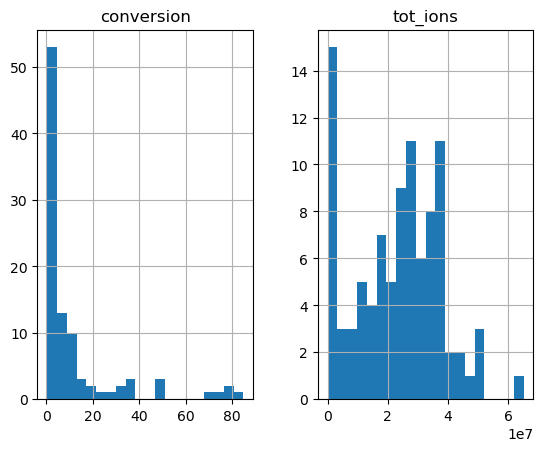

In [55]:
result_df.loc[:,['conversion','tot_ions']].hist(bins=20)

In [56]:
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,2.176894e+07,1.500178e+06,11.670124,2.326912e+07
std,1.334970e+07,3.187053e+06,18.864921,1.477855e+07
min,4.061000e+03,3.387000e+03,0.336434,9.295000e+03
25%,1.042829e+07,2.226730e+05,1.552658,1.086338e+07
50%,2.423789e+07,4.938055e+05,3.808315,2.460382e+07
75%,3.314439e+07,1.422624e+06,10.501439,3.504491e+07
max,4.494400e+07,2.038815e+07,84.798846,6.517994e+07


__filter out samples with low ion count__

In [60]:
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < 1739627.0, 'conversion'] = 0
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,2.176894e+07,1.500178e+06,4.902365,2.326912e+07
std,1.334970e+07,3.187053e+06,6.719641,1.477855e+07
min,4.061000e+03,3.387000e+03,0.000000,9.295000e+03
25%,1.042829e+07,2.226730e+05,0.992332,1.086338e+07
50%,2.423789e+07,4.938055e+05,2.699658,2.460382e+07
75%,3.314439e+07,1.422624e+06,5.478731,3.504491e+07
max,4.494400e+07,2.038815e+07,37.193232,6.517994e+07


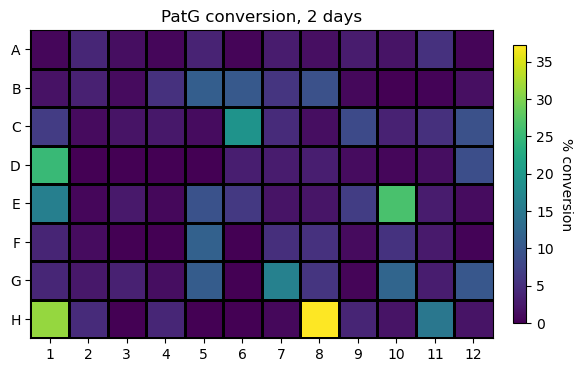

In [61]:
make_heatmap(result_df, 'PatG', '2 days','conversion')

## top 10 candidates for cyclization with PatG

In [66]:
result_df.to_csv('PatG-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].head(10)

,peptide,conversion
91,WHRFTTAPAYDG,37.193232
84,IFRYETAPAYDG,31.279786
57,HRFLWTAPAYDG,26.469910
36,YRGAWTAPAYDG,25.140185
29,VENWYTAPAYDG,19.053243
78,YGENWTAPAYDG,16.293263
48,GRFYKTAPAYDG,15.984111
94,ENFRDTAPAYDG,14.674467
81,IFDKFTAPAYDG,12.127951
64,AFWKVTAPAYDG,11.555943


# Analyze PatDfusion + ArtGox - 2 day reaction

In [16]:
PLOT=False
data_dir = 'data/PatDf-ArtG/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
lhr = ['LHR(m+1)', 'LHR(m+2)','LHR(m+3)']
lho = ['LHO(m+1)', 'LHO(m+2)','LHO(m+3)' ]

#combined list with expected ions
exp_ions = linear_ions + lhr + lho

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = 60
end = 240

In [17]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b', 'k']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            elif i >= 6:
                plt.plot(intensity[i], color = col[2])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatDf+ArtGox + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='heterocyclic reduced')
        black_patch = mpatches.Patch(color='k', label='heterocyclic oxidized')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch, black_patch])
        plt.savefig('output_patdf_artgox/'+str(exp_num)+'_PatDf_ArtGox_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['LHR(tot)'] = result_df.loc[:,lhr].sum(axis=1)
result_df['LHO(tot)'] = result_df.loc[:,lho].sum(axis=1)


In [18]:
# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,['LHO(tot)','LHR(tot)']].sum(axis=1)/result_df.loc[:,['LHO(tot)', 'LHR(tot)', 'L(tot)']].sum(axis=1)*100
result_df['tot_ions'] = result_df.loc[:, exp_ions].sum(axis=1)

In [19]:
result_df.sort_values('tot_ions').head(10)


,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions
78,YGENWTAPAYDG,216.0,1194.0,1336.0,888.0,1920.0,784.0,416.0,1912.0,4477.0,2746.0,3592.0,6805.0,79.106749,13143.0
64,AFWKVTAPAYDG,104.0,5034.0,994.0,962.0,1719.0,663.0,468.0,2210.0,3423.0,6132.0,3344.0,6101.0,60.634268,15577.0
76,IFGKNTAPAYDG,0.0,2695.0,1718.0,564.0,2834.0,2078.0,427.0,1834.0,5020.0,4413.0,5476.0,7281.0,74.298195,17170.0
66,WIETATAPAYDG,367.0,2468.0,4342.0,564.0,3528.0,2706.0,458.0,2189.0,1353.0,7177.0,6798.0,4000.0,60.072323,17975.0
53,YLHRITAPAYDG,322.0,4550.0,1145.0,347.0,3225.0,907.0,230.0,3198.0,4603.0,6017.0,4479.0,8031.0,67.523074,18527.0
61,RFIWATAPAYDG,458.0,3380.0,1485.0,244.0,2668.0,1552.0,206.0,2503.0,6685.0,5323.0,4464.0,9394.0,72.248579,19181.0
42,FQYTRTAPAYDG,259.0,1769.0,4227.0,101.0,1878.0,4673.0,110.0,2505.0,3980.0,6255.0,6652.0,6595.0,67.926367,19502.0
87,REYGNTAPAYDG,594.0,2693.0,2220.0,410.0,2610.0,1654.0,435.0,2772.0,6693.0,5507.0,4674.0,9900.0,72.576067,20081.0
54,KEYGNTAPAYDG,788.0,2247.0,5211.0,597.0,2725.0,5029.0,929.0,2111.0,1122.0,8246.0,8351.0,4162.0,60.277470,20759.0
89,YLEKFTAPAYDG,360.0,2894.0,4059.0,233.0,3003.0,4633.0,611.0,2977.0,2122.0,7313.0,7869.0,5710.0,64.996171,20892.0


In [20]:
result_df.sort_index(inplace=True)
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions,well
0,DVQAFTAPAYDG,1464.0,54060.0,55392.0,2772.0,54545.0,29428.0,2817.0,80600.0,89533.0,110916.0,86745.0,172950.0,70.072124,370611.0,A1
1,GYLKWTAPAYDG,879373.0,15114111.0,383801.0,6515.0,567000.0,106394.0,3658.0,50541.0,669252.0,16377285.0,679909.0,723451.0,7.892627,17780645.0,A2
2,GAEWRTAPAYDG,798605.0,15901463.0,423334.0,9030.0,619542.0,59036.0,1810.0,38112.0,80646.0,17123402.0,687608.0,120568.0,4.506999,17931578.0,A3
3,IDFVKTAPAYDG,22023.0,4029601.0,108911.0,1005.0,167188.0,124411.0,889.0,23042.0,57374.0,4160535.0,292604.0,81305.0,8.245972,4534444.0,A4
4,WLYKDTAPAYDG,765250.0,20645621.0,569798.0,5990.0,1250148.0,91437.0,2142.0,58570.0,35620.0,21980669.0,1347575.0,96332.0,6.164069,23424576.0,A5


In [21]:
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)','conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,1.152379e+07,7.526863e+05,1.210891e+05,26.873985,1.239757e+07
std,1.097836e+07,9.689263e+05,2.412480e+05,29.247233,1.180372e+07
min,2.746000e+03,3.092000e+03,4.000000e+03,3.022627,1.314300e+04
25%,9.137750e+03,1.013700e+04,1.207375e+04,5.252801,3.054925e+04
50%,1.010819e+07,5.576070e+05,7.840350e+04,7.896471,1.078773e+07
75%,2.062911e+07,1.116831e+06,1.310700e+05,61.424248,2.214151e+07
max,3.653582e+07,5.361028e+06,2.140428e+06,88.458377,3.894764e+07


In [27]:
cutoff = 4826505.0
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 0
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)', 'unfiltered_conversion', 'conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),unfiltered_conversion,conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,96.000000,9.600000e+01
mean,1.152379e+07,7.526863e+05,1.210891e+05,4.012092,4.012092,1.239757e+07
std,1.097836e+07,9.689263e+05,2.412480e+05,4.741255,4.741255,1.180372e+07
min,2.746000e+03,3.092000e+03,4.000000e+03,0.000000,0.000000,1.314300e+04
25%,9.137750e+03,1.013700e+04,1.207375e+04,0.000000,0.000000,3.054925e+04
50%,1.010819e+07,5.576070e+05,7.840350e+04,4.307474,4.307474,1.078773e+07
75%,2.062911e+07,1.116831e+06,1.310700e+05,5.896906,5.896906,2.214151e+07
max,3.653582e+07,5.361028e+06,2.140428e+06,25.645182,25.645182,3.894764e+07


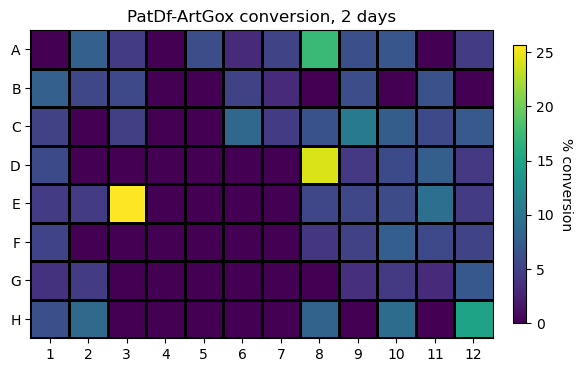

In [29]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

In [25]:
result_df.to_csv('PatDf-ArtGox-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['conversion','peptide','well']].head(10)

,conversion,peptide,well
50,25.645182,NKFERTAPAYDG,E3
43,24.210127,KWENFTAPAYDG,D8
7,17.286393,YVLRYTAPAYDG,A8
95,14.832731,FIRYQTAPAYDG,H12
32,10.558354,VKFWHTAPAYDG,C9
58,9.355989,KHFAATAPAYDG,E11
93,9.053605,ERIWQTAPAYDG,H10
85,8.824752,HFEAYTAPAYDG,H2
29,8.575769,VENWYTAPAYDG,C6
91,8.142191,WHRFTTAPAYDG,H8
